In [1]:
import json
import re
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
result_files = {
    "Base": "/raid/s3/opengptx/behzad_shomali/evaluation_results/teuken3.7B/results/Behzadshomali/Teuken3.7B/results_2025-08-27T14-52-13.185127.json",
    # "OpenMathInstruct-2 (5274)": "/raid/s3/opengptx/behzad_shomali/evaluation_results/teuken3.7B_IT_LoRA-OpenMathInstruct-2/2025_08_26-09_59_53_4096/checkpoint-5274/results/Behzadshomali/Teuken3.7B_IT_LoRA-OpenMathInstruct-2/results_2025-08-27T02-06-25.078549.json",
    # "OpenMathInstruct-2 (r=4096 all-linear/lm_head)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_26-09_59_53_4096/checkpoint-15823/hf_converted/results_2025-08-27T21-25-05.922917.json",
    "OpenMathInstruct-2 (r=1024)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_27-20_28_29/rank1024/checkpoint-4666/hf_converted/results_2025-08-28T17-01-19.206805.json",
    # "OpenMathInstruct-2 (r+=1024)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_30-01_31_25/rank1024/checkpoint-4666/lora_merged/results_2025-08-30T12-12-27.249412.json",
    "OpenMathInstruct-2 (r=512)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_28-04_49_19/rank512/checkpoint-4666/lora_merged/results_2025-08-28T21-19-43.752151.json",
    "Qwen3-4B-Base": "/raid/s3/opengptx/behzad_shomali/evaluation_results/Qwen/Qwen3-4B-Base/results/Qwen/Qwen3-4B-Base/results_2025-08-29T16-32-56.800414.json",
    "Qwen3-4B (r=512)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_29-12_22_48/rank512/checkpoint-4000/lora_merged/results_2025-08-29T21-20-41.801243.json",

    "OpenMathInstruct-2 (r+=512)": "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Teuken3.73T_IT_OpenMathInstruct-2/2025_08_30-16_23_44/rank512/checkpoint-4798/lora_merged/results_2025-08-31T18-52-09.829641.json"
}

In [3]:
def plot_result(
    result_file,
    ax,
    benchmarks_dict,
    legend=None,
    hatch="",
    index=0,
    total=1, 
    color=None
):
    results_json = json.load(open(result_file, "r"))
    labels, results, results_stderr = [], [], []
    for benchmark, metric in benchmarks_dict.items():
        labels.append(benchmark)
        results.append(results_json["results"][benchmark][metric])
        results_stderr.append(results_json["results"][benchmark][f"{metric}_stderr"])

    x = np.arange(len(labels))
    bar_width = 0.8 / total
    x_positions = x - 0.4 + index * bar_width + bar_width / 2

    ax.bar(
        x_positions,
        results,
        width=bar_width,
        label=legend,
        alpha=0.6,
        hatch=hatch,
        color=color
    )

    ax.errorbar(
        x_positions,
        results,
        yerr=results_stderr,
        fmt='o',
        color=color,
        capsize=0.5
    )

    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()

    return ax


In [4]:
benchmarks = {
    "leaderboard|arc:challenge|0": "acc_norm",
    "leaderboard|arc:challenge|5": "acc_norm",
    "leaderboard|gsm8k|0": "qem",
    "leaderboard|gsm8k|5": "qem",
    "leaderboard|hellaswag|0": "acc_norm",
    "leaderboard|hellaswag|5": "acc_norm",
    "leaderboard|mmlu:high_school_mathematics|0": "acc",
    "leaderboard|mmlu:high_school_mathematics|5": "acc",
    "leaderboard|truthfulqa:mc|0": "truthfulqa_mc2",
    "leaderboard|truthfulqa:mc|5": "truthfulqa_mc2"
}

In [5]:
colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#D55E00",  # red
    "#CC79A7",  # pink
    "#F0E442",  # yellow
    "#56B4E9",  # light blue
    "#999999"   # gray
]
patterns = [ "", "/" , "\\" , "|" , "-" , "+" , "x", "o", "O", ".", "*" ]

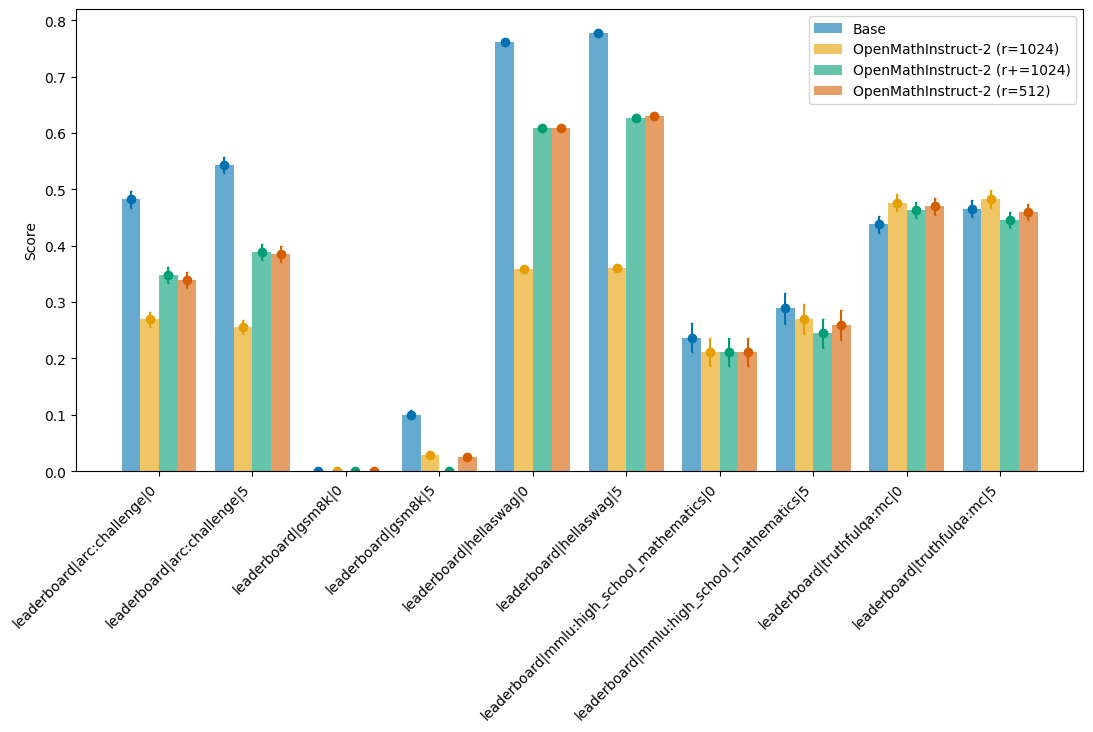

In [7]:

fig, ax = plt.subplots(figsize=(13, 6))

index = 0
for legend, result_file in result_files.items():
    if "qwen" in legend.lower():
        hatch = patterns[1]
    else:
        hatch = patterns[0]
        color = colors[index]
        ax = plot_result(result_file, ax, benchmarks, legend, hatch, index=index, total=len(result_files)-2, color=color)

    index += 1

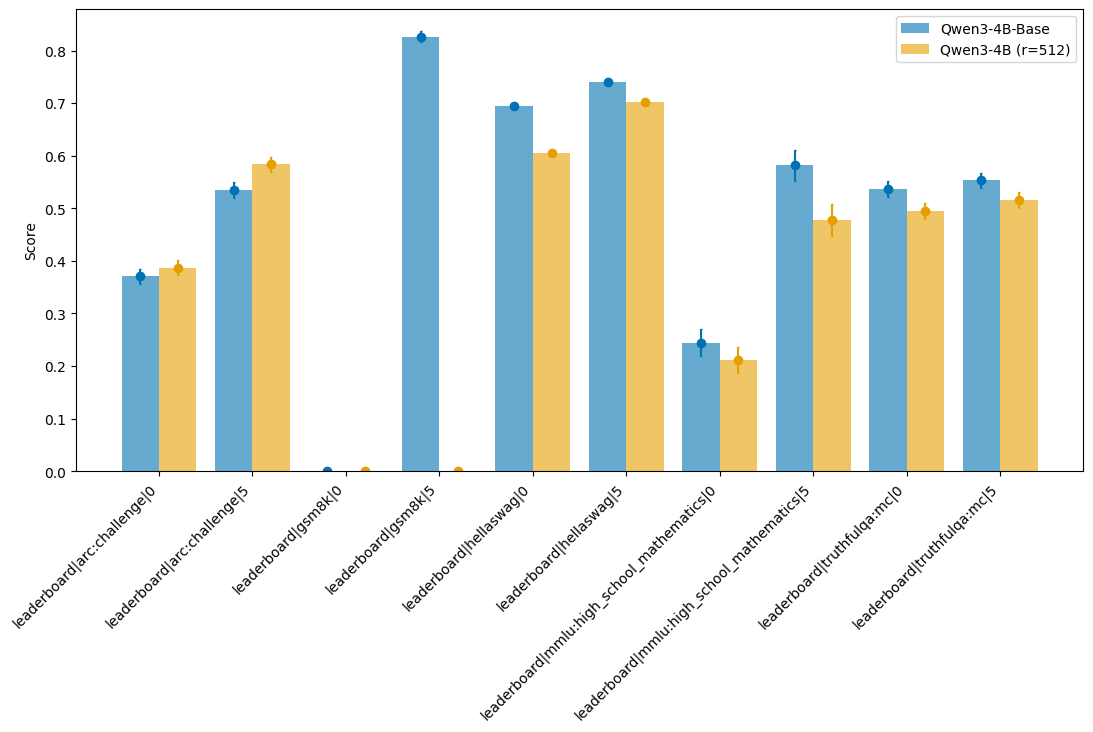

In [7]:

fig, ax = plt.subplots(figsize=(13, 6))

index = 0
for legend, result_file in result_files.items():
    if "qwen" in legend.lower():
        # hatch = patterns[1]
        hatch = patterns[0]
        color = colors[index]
        ax = plot_result(result_file, ax, benchmarks, legend, hatch, index=index, total=2, color=color)

        index += 1